# 1. Import Libraries

In [1]:
import numpy as np
import re

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

# Load Dataset

In [2]:
dataset = load_dataset("sh0416/ag_news")

train_data = dataset["train"]
test_data = dataset["test"]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
print(train_data)

Dataset({
    features: ['label', 'title', 'description'],
    num_rows: 120000
})


In [4]:
from collections import Counter

print(Counter(train_data["label"])) # how many samples per label

Counter({3: 30000, 4: 30000, 2: 30000, 1: 30000})


# Preprocessing

In [5]:
# remove lowercase and punctuation
# tokenize

def preprocess(text):

    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text) # removes punctuation
    tokens = text.split()

    return tokens

In [6]:
# example

preprocess("HelLo WorLd!")

['hello', 'world']

In [7]:
train_tokens = [
    preprocess(x["title"] + " " + x["description"])
    for x in train_data
]

test_tokens = [
    preprocess(x["title"] + " " + x["description"])
    for x in test_data
]

train_labels = np.array(
    [x["label"] - 1 for x in train_data], # -1 because labels start from 1 not 0
    dtype=np.int32
)

test_labels = np.array(
    [x["label"] - 1 for x in test_data],
    dtype=np.int32
)

# Naive Bayes Classifier
### Our goal is to compute the prob of class given text
### P ( C | W ) = P ( W | C ) * P ( C )

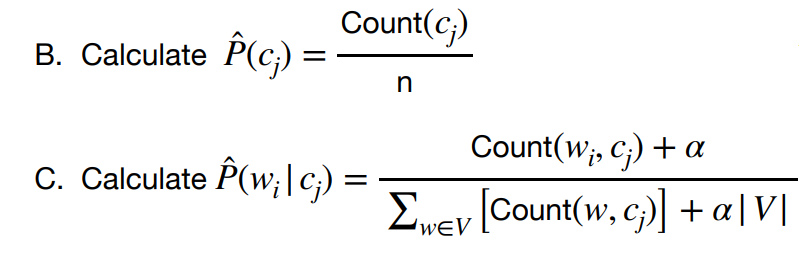

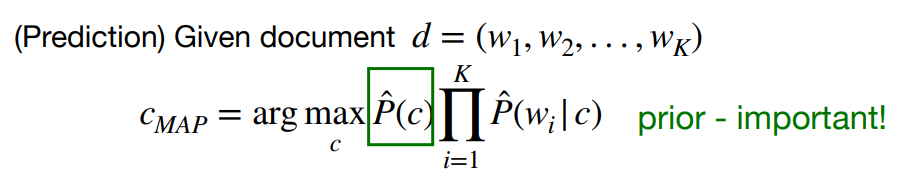

## Naive Bayes Scratch Implementation

In [8]:
class NaiveBayesScratch:
    """Multinomial Naive Bayes with Laplace smoothing."""

    def __init__(self, alpha=1.0):

        self.alpha = alpha

    def fit(self, token_lists, labels):
        # input
        # token_lists =
        # [
        #  ["i","love","movie"],
        #  ["movie","is","bad"]
        # ]
        # labels = [1,0]

        # get unique class labels (for example: 0 = negative, 1 = positive)
        self.classes_ = np.unique(labels)

        self.num_classes = len(self.classes_) # number of classes


        # 1. Build Vocabulary

        # vocabulary = all unique words in training data
        vocab = set()

        for toks in token_lists:     # toks = tokens of one document
            vocab.update(toks)       # add words to vocabulary set

        # sort words is asc order
        # then assign 0 based index to each word
        # this creats dictionary mapping each word to its unique index.
        # so model can work with numbers not with words
        self.vocab_ = {}
        sorted_vocab = sorted(vocab)
        for i, w in enumerate(sorted_vocab):
          self.vocab_[w] = i

        V = len(self.vocab_)


        # 2. Initialize Counters

        # will store documents per class
        # initially [ 0, 0, 0, 0]
        class_counts = np.zeros(self.num_classes, dtype=np.float32)

        # word counts per class
        # num of rows = number of classes
        # num of columns = size of vocabulary
        # example: how many times each word appears in each class
        token_counts = np.zeros((self.num_classes, V), dtype=np.float32)


        # 3 Count occurrences

        # go through every document and its label
        for toks, y in zip(token_lists, labels):

            # increase document count for class y
            class_counts[y] += 1

            # go through each word in the document
            for tok in toks:

                # if word exists in vocabulary
                if tok in self.vocab_:

                    # increase count for this word in class y

                    index = self.vocab_[tok]
                    token_counts[y, index] += 1 # counts how many times each word appears in each class



        # 4. Compute Prior Probabilities
        # P(class)
        # log_prior[c] = log(number of docs in class / total number of  docs)

        self.log_prior_ = np.log(class_counts / labels.shape[0]).astype(np.float32) # [p(class1), p(class2), p(class3), p(class4)]

        #  Laplace Smoothing
        smoothed = token_counts + self.alpha # fixes p(w|c) could be zero problem -> will cause naive bayes multiplication = 0


        #  Likelihood
        # compute P(word | class)

        self.log_likelihood_ = (
            np.log(smoothed) -                     # log[count of ( w,c) + alpha]
            np.log(smoothed.sum(axis=1, keepdims=True))  # normalize by total words in class
        ).astype(np.float32)

        return self


    def predict(self, token_lists):

        preds = [] # This will store predicted class for each document in the token list

        for toks in token_lists: # for each document

            log_post = self.log_prior_.copy() # prob of each class calculated in the fit function

            # add likelihood of each word
            for tok in toks: # for each word in the document

                # if word exists in vocabulary
                if tok in self.vocab_: # Test data may contain words not seen during training -> skipped
                    word_index =  self.vocab_[tok]
                    # add log P(word | class)
                    log_post += self.log_likelihood_[:, word_index] # prior × likelihood of all words

            # choose class with highest probability
            preds.append(int(np.argmax(log_post)))

        return np.array(preds, dtype=np.int32)

In [9]:
print("Training Naive Bayes (scratch)...")

nb_scratch = NaiveBayesScratch(alpha=1.0)

nb_scratch.fit(train_tokens, train_labels)

Training Naive Bayes (scratch)...


In [10]:
print("Predicting...")

nb_preds = nb_scratch.predict(test_tokens) # this will be used by evaluate model

Predicting...


In [11]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(test_labels, nb_preds)) # sklearn matrix

Accuracy: 0.9014473684210527


# Scikit-Learn Version

In [12]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [13]:
train_text = [
    x["title"] + " " + x["description"]
    for x in train_data
]

test_text = [
    x["title"] + " " + x["description"]
    for x in test_data
]

In [14]:
vectorizer = CountVectorizer(max_features=20000)

# each document is converted a vector of word counts
X_train = vectorizer.fit_transform(train_text)
X_test = vectorizer.transform(test_text)

In [15]:
nb = MultinomialNB()

nb.fit(X_train, train_labels)

MultinomialNB()

In [16]:
sk_preds = nb.predict(X_test)

In [17]:
print("Sklearn NB accuracy:",
      accuracy_score(test_labels, sk_preds)) # sklearn matrix

Sklearn NB accuracy: 0.8985526315789474


In [18]:
results = {}

# Evaluation

In [19]:
def confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=np.int32)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def metrics_from_cm(cm):
    num_classes = cm.shape[0]
    precision = np.zeros(num_classes, dtype=np.float32)
    recall    = np.zeros(num_classes, dtype=np.float32)
    f1        = np.zeros(num_classes, dtype=np.float32)

    for c in range(num_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        precision[c] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall[c]    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        if precision[c] + recall[c] > 0:
            f1[c] = 2 * precision[c] * recall[c] / (precision[c] + recall[c])

    return precision, recall, f1

def evaluate_model(name, y_true, y_pred):
    from sklearn.metrics import (confusion_matrix, precision_score,
                                 recall_score, f1_score)

    num_classes = len(np.unique(y_true))
    acc = (y_true == y_pred).mean()

    # --- Scratch metrics ---
    cm_scratch = confusion_matrix_np(y_true, y_pred, num_classes)
    p_per, r_per, f1_per = metrics_from_cm(cm_scratch)
    p_macro   = p_per.mean()
    r_macro   = r_per.mean()
    f1_macro  = f1_per.mean()

    # --- Sklearn metrics ---
    cm_sk     = confusion_matrix(y_true, y_pred)
    p_sk      = precision_score(y_true, y_pred, average=None)
    r_sk      = recall_score(y_true, y_pred, average=None)
    f1_sk     = f1_score(y_true, y_pred, average=None)
    p_sk_mac  = precision_score(y_true, y_pred, average='macro')
    r_sk_mac  = recall_score(y_true, y_pred, average='macro')
    f1_sk_mac = f1_score(y_true, y_pred, average='macro')

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"Accuracy: {acc:.4f}\n")

    print(f"{'Metric':<12} {'Class':>6} {'Scratch':>10} {'Sklearn':>10} {'Match':>6}")
    print("-" * 50)
    for c in range(num_classes):
        p_match  = "OK" if abs(p_per[c]  - p_sk[c])  < 1e-4 else "DIFF"
        r_match  = "OK" if abs(r_per[c]  - r_sk[c])  < 1e-4 else "DIFF"
        f1_match = "OK" if abs(f1_per[c] - f1_sk[c]) < 1e-4 else "DIFF"
        print(f"{'Precision':<12} {c:>6} {p_per[c]:>10.4f} {p_sk[c]:>10.4f} {p_match:>6}")
        print(f"{'Recall':<12} {c:>6} {r_per[c]:>10.4f} {r_sk[c]:>10.4f} {r_match:>6}")
        print(f"{'F1':<12} {c:>6} {f1_per[c]:>10.4f} {f1_sk[c]:>10.4f} {f1_match:>6}")
        print()

    print(f"{'--- Macro ---'}")
    print(f"{'Precision':<12} {'':>6} {p_macro:>10.4f} {p_sk_mac:>10.4f}")
    print(f"{'Recall':<12} {'':>6} {r_macro:>10.4f} {r_sk_mac:>10.4f}")
    print(f"{'F1':<12} {'':>6} {f1_macro:>10.4f} {f1_sk_mac:>10.4f}")

    print(f"\nConfusion Matrix (scratch):\n{cm_scratch}")
    print(f"\nConfusion Matrix (sklearn):\n{cm_sk}")

    results[name] = { # store the scratch matrix result
        "accuracy": acc,
        "precision": p_macro,
        "recall": r_macro,
        "f1": f1_macro
    }



In [23]:
del X_train
del X_test
import gc
gc.collect()

0

# Logistic Regression

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# create bigram features (pairs of words)
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2),  # bigrams
    binary=True,        # 1 if bigram exists: ex: feature vector x = [1, 0, 1, 0, 0] -> biagram 1 and 3 exist, rest doesn't
    # max_features=20000
)

# learn vocabulary + convert training text
X_train_bigram = bigram_vectorizer.fit_transform(train_text)

# convert test text using same vocabulary
X_test_bigram = bigram_vectorizer.transform(test_text)

print(X_train_bigram.shape)
print(X_test_bigram.shape)

(120000, 1226267)
(7600, 1226267)


In [25]:
X_train_lr = X_train_bigram.astype(np.float32)
X_test_lr = X_test_bigram.astype(np.float32)

# Logistic regression from scratch

In [26]:
class LogisticRegressionScratch:

    def __init__(self, lr=0.1, epochs=5, batch_size=256):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size

    def softmax(self, z):
        z -= z.max(axis=1, keepdims=True) # subtracts the largest value in each row.
        exp = np.exp(z)
        return exp / exp.sum(axis=1, keepdims=True)

    def fit(self, X, y):

        # X → feature matrix (biagram)
        # y → labels (class)

        n_samples, n_features = X.shape
        self.num_classes = len(np.unique(y))

        self.W = np.zeros((n_features, self.num_classes), dtype=np.float32)
        self.b = np.zeros(self.num_classes, dtype=np.float32)

        for epoch in range(self.epochs):

            idx = np.random.permutation(n_samples) # shuffle the dataset
            X = X[idx]
            y = y[idx]

            for i in range(0, n_samples, self.batch_size): # Mini-Batch Training

                X_batch = X[i:i+self.batch_size] # ex: (0-255) - (256-511) - and so on
                y_batch = y[i:i+self.batch_size]


                logits = X_batch @ self.W + self.b
                probs = self.softmax(logits)

                y_onehot = np.zeros((len(y_batch), self.num_classes), dtype=np.float32)
                y_onehot[np.arange(len(y_batch)), y_batch] = 1

                grad = (probs - y_onehot) / len(y_batch)

                grad_W = X_batch.T @ grad
                grad_b = grad.sum(axis=0)

                self.W -= self.lr * grad_W
                self.b -= self.lr * grad_b

        return self

    def predict(self, X):

        logits = X @ self.W + self.b
        return np.argmax(logits, axis=1)

In [27]:
lr_scratch = LogisticRegressionScratch()

lr_scratch.fit(X_train_lr, train_labels)

pred_lr_scratch = lr_scratch.predict(X_test_lr)

# evaluate_model("LogisticRegressionScratch", test_labels, pred_lr_scratch)

In [28]:
from sklearn.linear_model import LogisticRegression

lr_sk = LogisticRegression(max_iter=1000)

lr_sk.fit(X_train_bigram, train_labels)

pred_lr_sk = lr_sk.predict(X_test_bigram)

# evaluate_model("LogisticRegression_sklearn", test_labels, pred_lr_sk)

In [29]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(loss="log_loss", max_iter=10)

sgd.fit(X_train_bigram, train_labels)

pred_sgd = sgd.predict(X_test_bigram)

# evaluate_model("SGDClassifier_logistic", test_labels, pred_sgd)

In [30]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

cm = confusion_matrix(test_labels, pred_lr_sk)

print("Sklearn Confusion Matrix")
print(cm)

print("Precision:", precision_score(test_labels, pred_lr_sk, average="macro"))
print("Recall:", recall_score(test_labels, pred_lr_sk, average="macro"))
print("F1:", f1_score(test_labels, pred_lr_sk, average="macro"))

Sklearn Confusion Matrix
[[1683   66   73   78]
 [  32 1835   18   15]
 [  67   29 1621  183]
 [  46   25  134 1695]]
Precision: 0.8993454160786949
Recall: 0.8992105263157895
F1: 0.8990266402266435


In [32]:
# Run evaluation on all models
results = {}
evaluate_model("NB Scratch",                    test_labels, nb_preds)
evaluate_model("NB sklearn (MultinomialNB)",    test_labels, sk_preds)
evaluate_model("LR Scratch",                    test_labels, pred_lr_scratch)
evaluate_model("LR sklearn (LogisticRegression)", test_labels, pred_lr_sk)
evaluate_model("LR sklearn (SGDClassifier)",    test_labels, pred_sgd)

import pandas as pd
pd.DataFrame(results).T


  NB Scratch
Accuracy: 0.9014

Metric        Class    Scratch    Sklearn  Match
--------------------------------------------------
Precision         0     0.9136     0.9136     OK
Recall            0     0.8958     0.8958     OK
F1                0     0.9046     0.9046     OK

Precision         1     0.9505     0.9505     OK
Recall            1     0.9795     0.9795     OK
F1                1     0.9647     0.9647     OK

Precision         2     0.8719     0.8719     OK
Recall            2     0.8489     0.8489     OK
F1                2     0.8603     0.8603     OK

Precision         3     0.8683     0.8683     OK
Recall            3     0.8816     0.8816     OK
F1                3     0.8749     0.8749     OK

--- Macro ---
Precision               0.9011     0.9011
Recall                  0.9014     0.9014
F1                      0.9011     0.9011

Confusion Matrix (scratch):
[[1702   61   91   46]
 [  23 1861    7    9]
 [  70   18 1613  199]
 [  68   18  139 1675]]

Confusion Mat

,accuracy,precision,recall,f1
NB Scratch,0.901447,0.901064,0.901447,0.901129
NB sklearn (MultinomialNB),0.898553,0.898221,0.898553,0.898141
LR Scratch,0.801974,0.807540,0.801974,0.801996
LR sklearn (LogisticRegression),0.899211,0.899345,0.899211,0.899027
LR sklearn (SGDClassifier),0.895658,0.895775,0.895658,0.895376
